In [23]:
import os
import pandas as pd

In [24]:
# Importamos los datos
data = pd.read_csv("/content/sample_data/Datos_coches_numerico.csv")

In [25]:
data = data.dropna(axis=0)
# Comprobamos que no hay valores perdidos.
data.isnull().sum()
# Con esta funcion vemos si existen (TRUE) o no (FALSE) datos perdidos
data.isnull().any().any()

np.False_

In [26]:
data.columns

Index(['Unnamed: 0', 'Precio', 'Título', 'Combustible', 'Año', 'kilometraje',
       'Cambio', 'Potencia', 'B'],
      dtype='object')

In [27]:
data = data.drop(["Combustible"], axis=1)
data = data.rename(columns={"B": "Combustible"})
# El primer paso es conocer nuestros datos.
# Realizamos una primera visualizacion.
# EL objetivo es precedir la dureza del hormigón.
print(data)

      Unnamed: 0  Precio                                 Título   Año  \
0              1   11999                  Renault Talisman 2017  2017   
1              3    6999                    Renault Megane 2012  2012   
2              4    4500                    Renault Megane 2010  2010   
3              5    4999               Renault Laguna 4 CONTROL  2013   
4              6    5800                    Renault Kangoo 2017  2017   
...          ...     ...                                    ...   ...   
1957        2073    8900                         Renault 4 1992  1992   
1958        2074   12900                    Renault Kadjar 2017  2017   
1959        2075    6550                    Renault Trafic 2006  2006   
1960        2076   14790     Renault Captur Zen dCi 66kW (90CV)  2020   
1961        2077   11990  Renault Clio Intens TCe 74 kW (100CV)  2019   

      kilometraje      Cambio  Potencia Combustible  
0          158000      Manual       110      Diésel  
1          1660

In [28]:
one_hot = pd.get_dummies(data['Combustible'])
# Drop column B as it is now encoded
data = data.drop('Combustible', axis=1)
# Join the encoded df
data = data.join(one_hot)

In [29]:
data["Cambio"].replace("Automático", 1, inplace=True)
data["Cambio"].replace("Manual", 0, inplace=True)

/tmp/ipython-input-29-957507286.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Cambio"].replace("Automático", 1, inplace=True)
/tmp/ipython-input-29-957507286.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [30]:
# Visualizamos los 10 primero datos, de una manera mas comoda.
data.head(n=10)

,Unnamed: 0,Precio,Título,Año,kilometraje,Cambio,Potencia,Diésel,Eléctrico,Gasolina,Hybrid,Otros
0,1,11999,Renault Talisman 2017,2017,158000,0,110,True,False,False,False,False
1,3,6999,Renault Megane 2012,2012,166000,0,115,False,False,True,False,False
2,4,4500,Renault Megane 2010,2010,212580,0,110,True,False,False,False,False
3,5,4999,Renault Laguna 4 CONTROL,2013,316000,1,175,True,False,False,False,False
4,6,5800,Renault Kangoo 2017,2017,233000,0,75,True,False,False,False,False
5,7,5999,Renault Grand Scenic 2014,2014,250000,0,110,True,False,False,False,False
6,8,9900,Renault Megane 2019,2019,115000,0,115,True,False,False,False,False
7,9,22000,Renault Trafic 2022,2022,35000,0,110,True,False,False,False,False
8,10,3500,Renault Megane 2004,2004,152000,0,80,True,False,False,False,False
9,11,8300,Renault Kangoo 2019,2019,114031,0,90,True,False,False,False,False


In [31]:
# Realizamos un resumen estadistico de las variables.
descripcion = data.describe(include="all").T

In [32]:
descripcion

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1839.0,NaN,NaN,NaN,1066.144644,587.328555,1.0,554.5,1082.0,1576.5,2077.0
Precio,1839.0,NaN,NaN,NaN,14110.395867,9139.366357,0.0,7997.0,13490.0,18690.0,82900.0
Título,1839,1099,Mercedes-Benz Citan 1.5 CDI 109 Furgón 90CV,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Año,1839.0,NaN,NaN,NaN,2016.302882,6.08948,1980.0,2015.0,2019.0,2020.0,2024.0
kilometraje,1839.0,NaN,NaN,NaN,142195.892333,791700.453133,1.0,61627.0,102173.0,148557.5,33400000.0
Cambio,1839.0,NaN,NaN,NaN,0.162045,0.368592,0.0,0.0,0.0,0.0,1.0
Potencia,1839.0,NaN,NaN,NaN,123.894508,266.69857,13.0,95.0,115.0,130.0,11290.0
Diésel,1839,2,True,1332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Eléctrico,1839,2,False,1801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasolina,1839,2,False,1415,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1839 entries, 0 to 1961
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1839 non-null   int64 
 1   Precio       1839 non-null   int64 
 2   Título       1839 non-null   object
 3   Año          1839 non-null   int64 
 4   kilometraje  1839 non-null   int64 
 5   Cambio       1839 non-null   int64 
 6   Potencia     1839 non-null   int64 
 7   Diésel       1839 non-null   bool  
 8   Eléctrico    1839 non-null   bool  
 9   Gasolina     1839 non-null   bool  
 10  Hybrid       1839 non-null   bool  
 11  Otros        1839 non-null   bool  
dtypes: bool(5), int64(6), object(1)
memory usage: 123.9+ KB


# Representaciones gráficas de los datos

In [34]:
# Importaciones para graficas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data_num = data.select_dtypes(include=[np.number])

<Axes: >

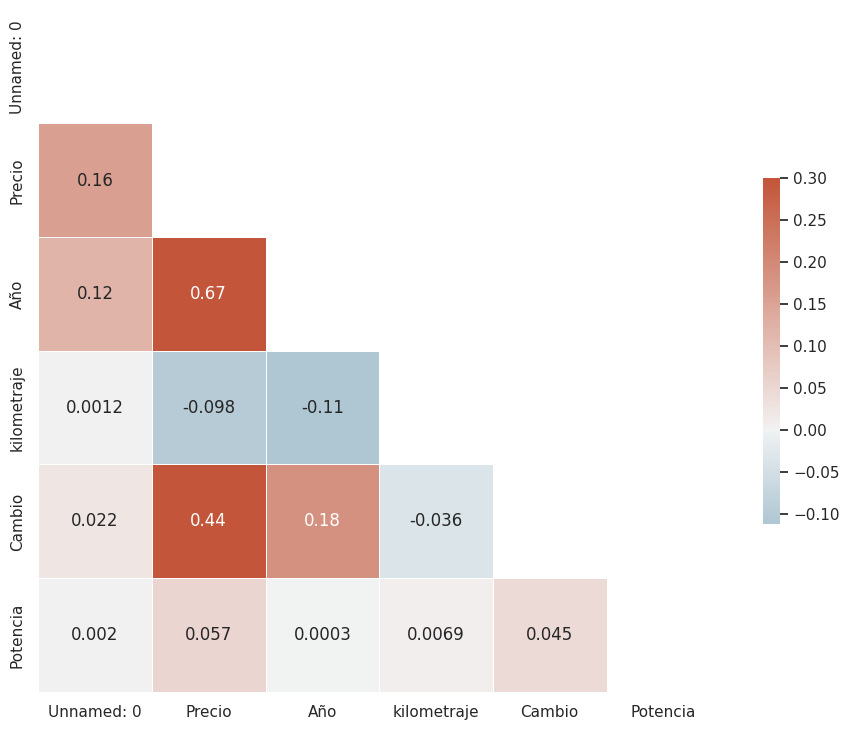

In [36]:
# Representaciones gráficas de los datos:
from string import ascii_letters
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Compute the correlation matrix
corr = data_num.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [37]:
# Este gráfico no admite NAs
datoscompletos = data.dropna()
# sns.pairplot(datoscompletos)

Intentamos "limitar" nuestro estudio a los datos para los que tiene sentido hacer un modelo de predicción

In [38]:
# Quitar los que no son renault
data = data[data["Título"].str.contains("enault")]

In [39]:
# Quedarnos con los precios entre 1000 y 25000
data = data[data['Precio'].between(1000, 25000)]
# kilómetros entre 1000 y 300000
data = data[data['kilometraje'].between(1000, 300000)]

In [40]:
data = data[data["Año"] > 1995]
data = data[data["Potencia"].between(50, 180)]

In [41]:
data = data.drop('Título', axis=1)
data = data.drop('Unnamed: 0', axis=1)

Una vez que comprobamos que los datos son correctos pasamos a la modelizacion, utilizando tecnicas de machine learning.

Cuando realizamos un modelo predictivo es necesario conocer la fiabilidad esperada con datos futuros.

Para ello podemos hacer una particion y utilizar unos datos para entrenar el modelo (train) y otros para comprobar la fiabilidad (test).

# Modelo de Regresión

Realizamos una particion simple de los datos.

800 datos para entrenar el modelo y 230 para comprobar su fiabilidad.

El siguiente paso es realizar la particion de forma aleatoria.

Primero separamos la variable dependiente del resto.

In [42]:
objetivo = "Precio"
y = data[objetivo]
X = data.drop([objetivo], axis=1)

Realizamos la particion dejando un 75% para entrenar y un 25% de test.

In [43]:
# Separación train test automática
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 42)

In [44]:
X_train

,Año,kilometraje,Cambio,Potencia,Diésel,Eléctrico,Gasolina,Hybrid,Otros
392,2019,118822,0,75,True,False,False,False,False
970,2020,37316,0,115,True,False,False,False,False
463,2017,92248,0,110,True,False,False,False,False
342,2023,48809,0,110,True,False,False,False,False
364,2018,107000,0,75,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
136,2022,21016,0,95,True,False,False,False,False
488,2013,116360,0,90,True,False,False,False,False
645,2019,39800,1,175,True,False,False,False,False
218,2022,78323,0,115,True,False,False,False,False


# Aplicamos un modelo de árbol de decisión

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Normalización

In [46]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
data_sin_columnas = ss.fit_transform(data)
datos_normalizados = pd.DataFrame(data_sin_columnas, columns = data.columns)

Si no se desea usar datos normalizados ejecutar esta celda para recuperar los originales

In [47]:
datos_normalizados = data.copy()

In [48]:
datos_normalizados.describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,1036.0,11274.221042,5892.583682,1000.0,6500.00,11990.0,15785.0,24727.0
Año,1036.0,2015.464286,5.833907,1998.0,2013.00,2018.0,2019.0,2023.0
kilometraje,1036.0,117344.967181,72810.896428,3000.0,63476.75,101358.5,160000.0,300000.0
Cambio,1036.0,0.137066,0.344083,0.0,0.00,0.0,0.0,1.0
Potencia,1036.0,110.287645,24.696149,60.0,90.00,110.0,130.0,180.0


In [49]:
# Separar las variables dependiente e independientes
objetivo = 'Precio'
y = datos_normalizados[objetivo]
X = datos_normalizados.drop(objetivo, axis=1)

In [50]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [51]:
# Crear y ajustar el modelo de árbol de decisión para regresión
model = DecisionTreeRegressor(max_depth=8, min_samples_split = 9, min_samples_leaf=5,
                            splitter='random')

In [ ]:
"""
model = DecisionTreeRegressor(criterion='squared_error',
                              max_depth=15,
                              max_features=None,
                              max_leaf_nodes=None,
                              min_impurity_decrease=0.0,
                              min_samples_leaf=5,
                              min_samples_split=2,
                              min_weight_fraction_leaf=0.0,
                              random_state=None,
                              splitter='best')
"""

"\nmodel = DecisionTreeRegressor(criterion='squared_error',\n                              max_depth=15,\n                              max_features=None,\n                              max_leaf_nodes=None,\n                              min_impurity_decrease=0.0,\n                              min_samples_leaf=5,\n                              min_samples_split=2,\n                              min_weight_fraction_leaf=0.0,\n                              random_state=None,\n                              splitter='best')\n"

In [52]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=9,
                      splitter='random')

In [53]:
# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

## Funciones de error

In [54]:
# Funciones de error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### R²
El coeficiente de determinación R² mide la proporción de la variabilidad en la variable dependiente que es explicada por el modelo. Su valor varía entre 0 y 1, y en algunos casos, puede ser negativo.

- **Mejor Posible Valor:**
  - El mejor valor posible de R² es 1.0. Esto indicaría que el modelo explica el 100% de la variabilidad en la variable dependiente, es decir, todas las observaciones caen exactamente en la línea de regresión.

- **Valor Nulo:**
  - Un R² de 0.0 indica que el modelo no explica ninguna variabilidad en la variable dependiente. Podría interpretarse como si el modelo es tan malo como un modelo constante que siempre predice el valor medio de la variable dependiente, sin importar los valores de las variables independientes.

- **Valor Negativo:**
  - En algunos casos, especialmente cuando se utilizan modelos muy malos, el R² puede ser negativo. Esto significa que el modelo es tan pobre que incluso un modelo constante sería mejor.

Entonces, si el modelo siempre predice el valor de y, el mejor valor posible de R² debería ser 1.0, ya que eso indicaría que el modelo explica el 100% de la variabilidad en la variable dependiente. Si el R² es 0.0, significa que el modelo no está proporcionando ninguna mejora sobre un modelo constante que siempre predice el valor medio de y. La interpretación es relativa al rendimiento del modelo en comparación con un modelo nulo o constante.

### Mean Squared Error (MSE):

- **Definición:**
  - El MSE es una medida de la magnitud cuadrática de los errores entre las predicciones de un modelo y los valores reales.

- **Interpretación:**
  - Cuanto menor sea el MSE, mejor. Indica que las predicciones del modelo están más cerca de los valores reales. Los errores más grandes tienen un impacto cuadrático en el MSE.

### Mean Absolute Error (MAE):

- **Definición:**
  - El MAE es una medida de la magnitud promedio de los errores absolutos entre las predicciones de un modelo y los valores reales.


- **Interpretación:**
  - Cuanto menor sea el MAE, mejor. Indica que las predicciones del modelo están más cerca de los valores reales. Los errores más grandes tienen un impacto lineal en el MAE.

### Diferencias

- **Sensibilidad a Outliers:**
  - El MSE penaliza más fuertemente los errores grandes debido al término cuadrático. Por lo tanto, es más sensible a outliers que el MAE.

- **Interpretación:**
  - Ambos indicadores miden la calidad de las predicciones, pero la elección entre MSE y MAE depende del énfasis en la sensibilidad a errores grandes y la robustez a outliers en el problema específico.

In [55]:
# Calcular métricas de rendimiento
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [56]:
# Imprimir las métricas de rendimiento
print(f'R al cuadrado (R²): {round(r2_score(y_test, y_pred), 4)} Objetivo --> 1')
print(f'Error Cuadrático Medio (Mean Squared Error MSE): {round(mean_squared_error(y_test, y_pred),2)} Objetivo --> 0')
print(f'Error Absoluto Medio (Mean Absolute Error MAE): {round(mean_absolute_error(y_test, y_pred), 2)} Objetivo --> 0')

R al cuadrado (R²): 0.8387 Objetivo --> 1
Error Cuadrático Medio (Mean Squared Error MSE): 6381386.76 Objetivo --> 0
Error Absoluto Medio (Mean Absolute Error MAE): 1844.93 Objetivo --> 0


Visualizamos el modelo para una mejor comprension.

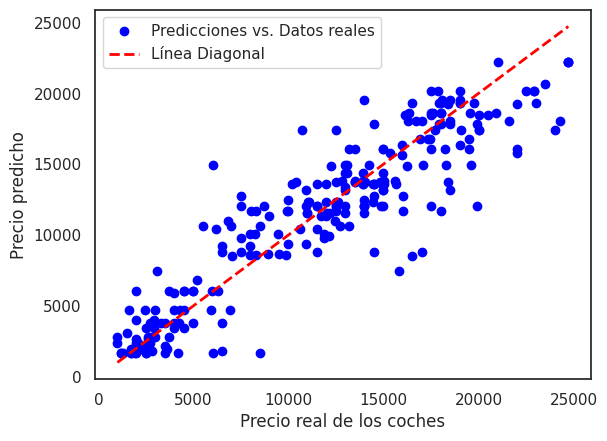

In [57]:
import matplotlib.pyplot as plt

# Visualizar los resultados
plt.scatter(y_test, y_pred, color='blue', label='Predicciones vs. Datos reales')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Línea Diagonal')
plt.xlabel('Precio real de los coches')
plt.ylabel('Precio predicho')
plt.legend()
plt.show()

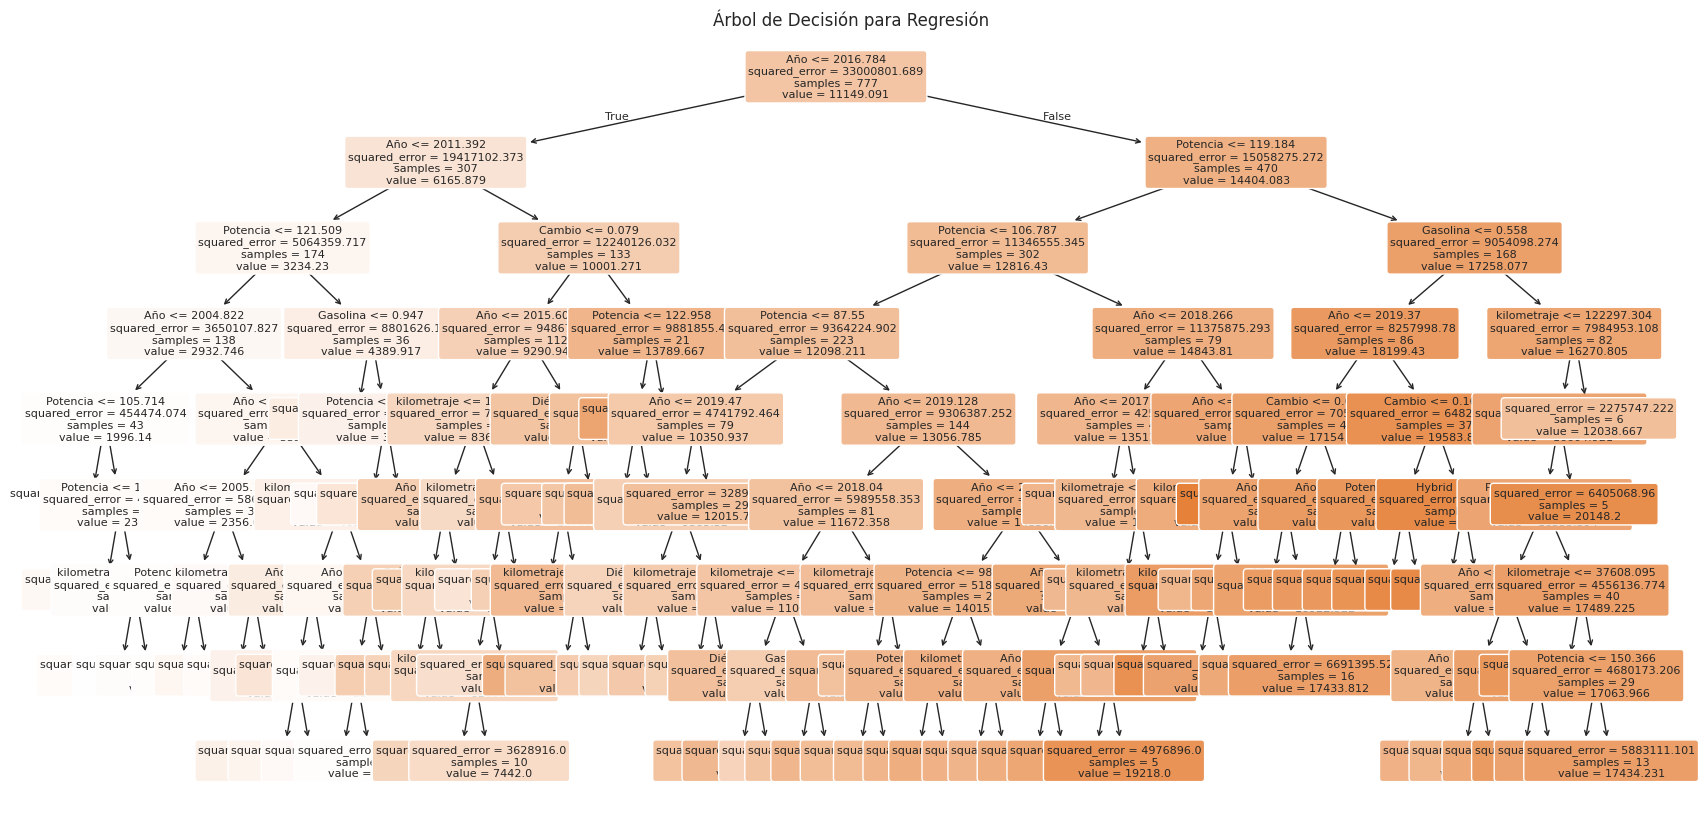

In [58]:
# Representación gráfica del árbol de decisión
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualizar el árbol de decisión (solo las primeras capas si es muy grande)
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns.tolist(), filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión para Regresión")
plt.show()
